# Part A: Data Preparation

In [225]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [226]:
market_sentiment = pd.read_csv('fear_greed_index.csv')
trader = pd.read_csv('historical_data.csv')

In [227]:
market_sentiment

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [228]:
trader

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


In [229]:
market_sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [230]:
market_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [231]:
market_sentiment.shape

(2644, 4)

In [232]:
market_sentiment.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [233]:
market_sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [234]:
market_sentiment.duplicated().sum()

np.int64(0)

In [235]:
## converting date
market_sentiment['date'] = pd.to_datetime(market_sentiment['date'])

In [236]:
market_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB


In [237]:
market_sentiment_copy = market_sentiment.copy()

In [238]:
def simplify_sentiment(x):
    if 'Fear' in x:
        return 'Fear'
    elif 'Greed' in x:
        return 'Greed'
    else:
        return 'Neutral'

market_sentiment['sentiment'] = market_sentiment['classification'].apply(simplify_sentiment)

In [239]:
market_sentiment

,timestamp,value,classification,date,sentiment
0,1517463000,30,Fear,2018-02-01,Fear
1,1517549400,15,Extreme Fear,2018-02-02,Fear
2,1517635800,40,Fear,2018-02-03,Fear
3,1517722200,24,Extreme Fear,2018-02-04,Fear
4,1517808600,11,Extreme Fear,2018-02-05,Fear
...,...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28,Neutral
2640,1745904600,60,Greed,2025-04-29,Greed
2641,1745991000,56,Greed,2025-04-30,Greed
2642,1746077400,53,Neutral,2025-05-01,Neutral


([0, 1, 2], [Text(0, 0, 'Fear'), Text(1, 0, 'Neutral'), Text(2, 0, 'Greed')])

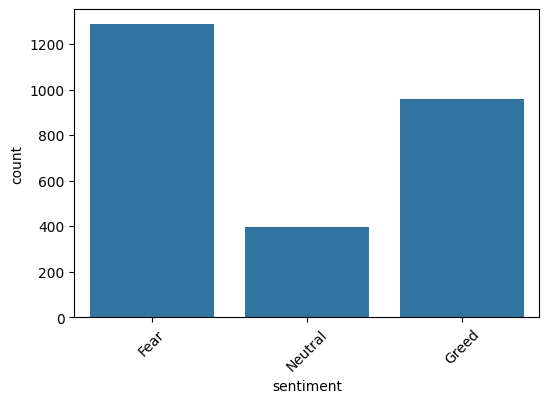

In [240]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment' , data = market_sentiment)
plt.xticks(rotation=45)

<Axes: xlabel='value', ylabel='Count'>

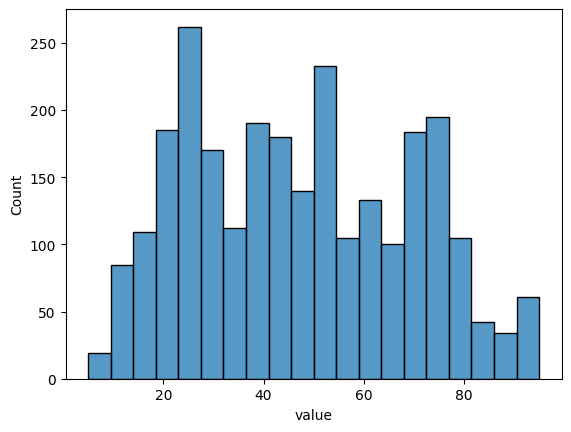

In [241]:
sns.histplot(market_sentiment['value'], bins=20)

In [242]:
## trader
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [243]:
trader.shape

(211224, 16)

In [244]:
trader.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [245]:
trader.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [246]:
trader.duplicated().sum()

np.int64(0)

In [247]:
trader.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [248]:
## Renaming column
trader.columns = trader.columns.str.strip().str.lower().str.replace(' ', '_')

In [249]:
trader.columns

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')

In [250]:
trader['timestamp_ist'] = pd.to_datetime(trader['timestamp_ist'], dayfirst=True)

In [251]:
trader['date'] = trader['timestamp_ist'].dt.date

In [252]:
trader.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   account           211224 non-null  object        
 1   coin              211224 non-null  object        
 2   execution_price   211224 non-null  float64       
 3   size_tokens       211224 non-null  float64       
 4   size_usd          211224 non-null  float64       
 5   side              211224 non-null  object        
 6   timestamp_ist     211224 non-null  datetime64[ns]
 7   start_position    211224 non-null  float64       
 8   direction         211224 non-null  object        
 9   closed_pnl        211224 non-null  float64       
 10  transaction_hash  211224 non-null  object        
 11  order_id          211224 non-null  int64         
 12  crossed           211224 non-null  bool          
 13  fee               211224 non-null  float64       
 14  trad

In [253]:
trader['date'] = pd.to_datetime(trader['date']).dt.normalize()
market_sentiment['date'] = pd.to_datetime(market_sentiment['date']).dt.normalize()

In [254]:
trader[['timestamp_ist','date']].head()

,timestamp_ist,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [255]:
trader.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [256]:
merged = trader.merge(market_sentiment, on='date', how='left')

In [257]:
merged.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,...,order_id,crossed,fee,trade_id,timestamp_x,date,timestamp_y,value,classification,sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,Greed


In [258]:
merged.columns

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp_x', 'date', 'timestamp_y', 'value', 'classification',
       'sentiment'],
      dtype='object')

In [259]:
merged.isnull().sum()

account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp_x         0
date                0
timestamp_y         6
value               6
classification      6
sentiment           6
dtype: int64

In [260]:
merged = merged.dropna(subset=['sentiment'])

In [261]:
merged.isnull().sum()

account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp_x         0
date                0
timestamp_y         0
value               0
classification      0
sentiment           0
dtype: int64

In [262]:
merged.duplicated().sum()

np.int64(0)

In [263]:
merged['win'] = merged['closed_pnl'] > 0

In [264]:
merged[['closed_pnl','win']]

,closed_pnl,win
0,0.0000,False
1,0.0000,False
2,0.0000,False
3,0.0000,False
4,0.0000,False
...,...,...
211219,-20.2566,False
211220,-112.5773,False
211221,-22.4402,False
211222,-190.7894,False


In [265]:
daily_pnl = merged.groupby(['account','date'])['closed_pnl'].sum().reset_index()

In [266]:
daily_pnl.head()

,account,date,closed_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [267]:
daily_pnl.describe()

,date,closed_pnl
count,2340,2340.000000
mean,2024-12-22 01:24:55.384615680,4382.259380
min,2023-05-01 00:00:00,-358963.139984
25%,2024-11-28 00:00:00,0.000000
50%,2025-01-28 00:00:00,206.352695
75%,2025-03-18 00:00:00,1842.763729
max,2025-05-01 00:00:00,533974.662903
std,NaN,28411.103383


In [268]:
win_rate = merged.groupby('account')['win'].mean().reset_index()

In [269]:
win_rate.head()

,account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [270]:
win_rate.describe()

,win
count,32.000000
mean,0.402971
std,0.108583
min,0.234987
25%,0.329562
50%,0.391968
75%,0.452963
max,0.810876


In [271]:
avg_trade_size = merged.groupby('account')['size_usd'].mean().reset_index()

In [272]:
avg_trade_size.head()

,account,size_usd
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [273]:
avg_trade_size.describe()

,size_usd
count,32.000000
mean,6006.264455
std,7281.979090
min,507.626933
25%,2011.069878
50%,3327.972048
75%,7375.525018
max,34396.580284


In [274]:
trades_per_day = merged.groupby('date').size().reset_index(name='trade_count')

In [275]:
trades_per_day.head()

,date,trade_count
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [276]:
trades_per_day.describe()

,date,trade_count
count,479,479.000000
mean,2024-08-25 13:55:44.467640832,440.956159
min,2023-05-01 00:00:00,1.000000
25%,2024-04-22 12:00:00,18.500000
50%,2024-08-25 00:00:00,68.000000
75%,2025-01-01 12:00:00,521.000000
max,2025-05-01 00:00:00,6246.000000
std,NaN,810.351623


In [277]:
long_short_ratio = merged['side'].value_counts(normalize=True)

In [278]:
long_short_ratio

side
SELL    0.51382
BUY     0.48618
Name: proportion, dtype: float64

# PART B - Analysis 

In [279]:
## merging daily trader performance with market sentiment to analyze how Fear and Greed impact the profitability.
daily_pnl = daily_pnl.merge(market_sentiment[['date','sentiment']],on='date',how='left')

In [280]:
daily_pnl

,account,date,closed_pnl,sentiment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,Greed
...,...,...,...,...
2335,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,Greed
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,Neutral
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,Greed
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,Greed


In [281]:
## Average
daily_pnl.groupby('sentiment')['closed_pnl'].mean()

sentiment
Fear       5185.146443
Greed      4144.208334
Neutral    3438.618818
Name: closed_pnl, dtype: float64

In [282]:
daily_pnl.groupby('sentiment')['closed_pnl'].median()  ### Data is right skewed

sentiment
Fear       122.737038
Greed      265.247725
Neutral    167.551743
Name: closed_pnl, dtype: float64

Text(0.5, 1.0, 'PnL Distribution by Sentiment')

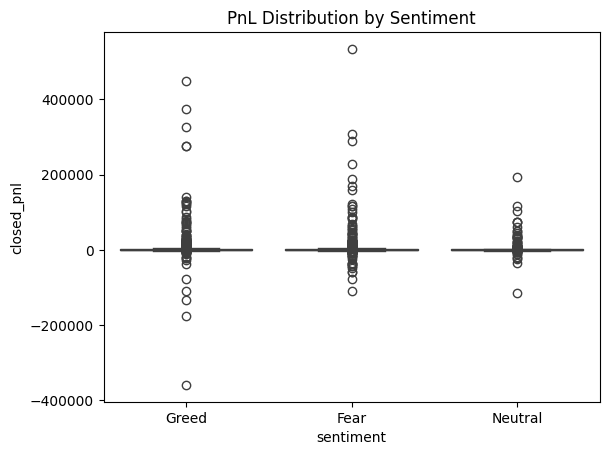

In [300]:
sns.boxplot(x='sentiment', y='closed_pnl', data=daily_pnl)
plt.title("PnL Distribution by Sentiment")

In [284]:
merged.groupby('sentiment')['win'].mean() ## Trade Frequency

sentiment
Fear       0.407871
Greed      0.420311
Neutral    0.396991
Name: win, dtype: float64

Text(0.5, 1.0, 'Trade Frequency by Sentiment')

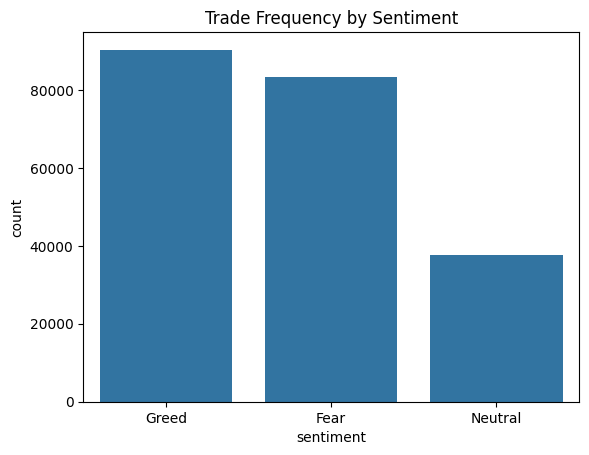

In [301]:
sns.countplot(x='sentiment', data=merged)
plt.title("Trade Frequency by Sentiment")

In [285]:
merged.groupby('sentiment')['closed_pnl'].min() ## Drawdown proxy

sentiment
Fear       -35681.74723
Greed     -117990.10410
Neutral    -24500.00000
Name: closed_pnl, dtype: float64

In [286]:
merged.groupby('sentiment').size()

sentiment
Fear       83237
Greed      90295
Neutral    37686
dtype: int64

In [287]:
merged.groupby('sentiment')['size_usd'].mean() #Position size

sentiment
Fear       7182.011019
Greed      4574.424490
Neutral    4782.732661
Name: size_usd, dtype: float64

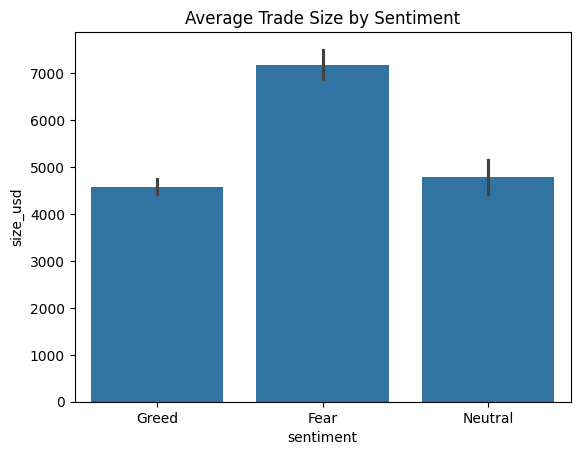

In [299]:
sns.barplot(x='sentiment', y='size_usd', data=merged)
plt.title("Average Trade Size by Sentiment")
plt.show()

In [288]:
merged.groupby('sentiment')['side'].value_counts(normalize=True) ## Long short Bias

sentiment  side
Fear       SELL    0.504968
           BUY     0.495032
Greed      SELL    0.529143
           BUY     0.470857
Neutral    BUY     0.503343
           SELL    0.496657
Name: proportion, dtype: float64

SEGMENTATION


In [289]:
#Frequent vs Infrequent Traders
trader_freq = merged.groupby('account').size().reset_index(name='trade_count')

In [290]:
threshold = trader_freq['trade_count'].median()

In [291]:
trader_freq['segment'] = trader_freq['trade_count'].apply(
    lambda x: 'High Frequency' if x > threshold else 'Low Frequency'
)

In [292]:
merged = merged.merge(trader_freq[['account','segment']], on='account', how='left')

In [293]:
merged.groupby(['segment','sentiment'])['closed_pnl'].mean()

segment         sentiment
High Frequency  Fear          47.325875
                Greed         41.476621
                Neutral       34.579701
Low Frequency   Fear          61.968833
                Greed        155.896341
                Neutral       31.845656
Name: closed_pnl, dtype: float64

In [294]:
# Winners vs Losers
win_rate = merged.groupby('account')['win'].mean().reset_index()

In [295]:
win_rate['segment'] = win_rate['win'].apply(
    lambda x: 'Winner' if x > 0.5 else 'Loser'
)

In [296]:
merged = merged.merge(win_rate[['account','segment']], on='account', how='left', suffixes=('','_win'))

In [297]:
merged.groupby(['segment_win','sentiment'])['closed_pnl'].mean()

segment_win  sentiment
Loser        Fear         49.848419
             Greed        53.297018
             Neutral      35.601722
Winner       Fear         28.846388
             Greed        59.482216
             Neutral      15.961843
Name: closed_pnl, dtype: float64

# PART C - Actionable output


Strategy 1 - Be More Cautious in Greedy Markets

Traders generally perform better during greed periods but the data also shows that the biggest losses happen during these times. This suggests that while the market looks attractive, it can also be risky if trades go wrong.
 
This is the analysis where Greed shows higher median PnL but also the largest drawdowns
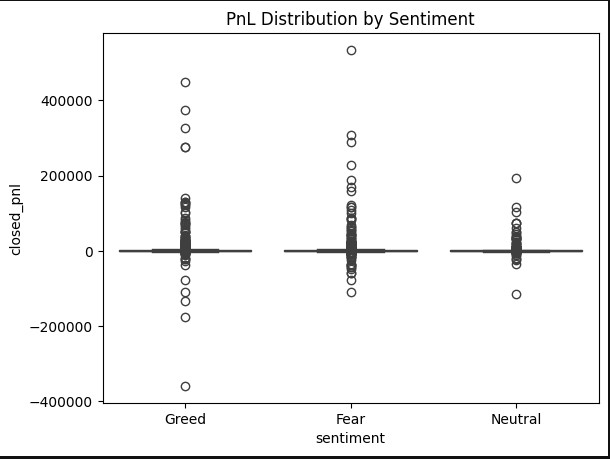

Recommendations: During Greed periods, traders should avoid overconfidence. It’s better to control risk by using smaller position sizes or setting stricter stop-loss levels instead of going all-in.

Strategy 2 - Focus on Consistency Over Big Wins

The analysis indicated that a few large trades heavily influence overall profits while most trades generate relatively small returns. This means chasing big wins is not a reliable strategy.

Recommendation:
Traders should aim for consistent, smaller profits rather than trying to capture giant or huge gains. A disciplined approach with steady returns can lead to better long-term performance.

Strategy 3 - Increase Activity Strategically in Greed and stay selective in fear

Traders tend to trade more during Greed periods likely due to higher confidence and clearer market direction and on the other hand, Fear periods are more unpredictable.

The frequency analysis shows that trading activity is highest during Greed periods.



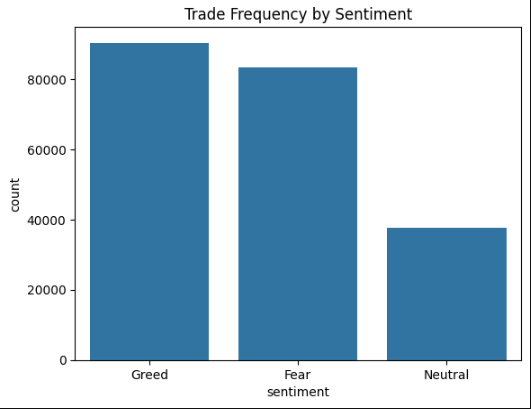





Recommendation:
It can be beneficial to be more active during Greed phases but with proper risk management. During Fear periods traders should be more selective and avoid unnecessary trades, as market conditions are uncertain.


Strategy 4 - Adapt Trading Style Based on Market Sentiment

The analysis clearly shows that trader behavior and outcomes change with sentiment. One fixed strategy may not work well across all conditions.

Recommendation:
Traders should adapt their strategies based on market sentiment
* In Greed focus on controlled risk and consistency
* In Fear prioritize capital preservation and cautious trading

In [302]:
daily_pnl

,account,date,closed_pnl,sentiment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,Greed
...,...,...,...,...
2335,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,Greed
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,Neutral
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,Greed
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,Greed


# SIMPLE ML MODEL 

In [303]:
daily_pnl['target'] = (daily_pnl['closed_pnl'] > 0).astype(int)

In [304]:
daily_pnl

,account,date,closed_pnl,sentiment,target
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,Greed,0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,Greed,0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,Greed,0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,Greed,0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,Greed,1
...,...,...,...,...,...
2335,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,Greed,1
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,Neutral,1
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,Greed,1
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,Greed,1


In [308]:
X = daily_pnl.drop(['account', 'date', 'closed_pnl', 'target'], axis=1)
y = daily_pnl['target']

In [309]:
## One hot eUnicoding
X = pd.get_dummies(X, drop_first=True)

In [310]:
X

,sentiment_Greed,sentiment_Neutral
0,True,False
1,True,False
2,True,False
3,True,False
4,True,False
...,...,...
2335,True,False
2336,False,True
2337,True,False
2338,True,False


In [313]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [315]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [316]:
## EVALUATION OF MODEL
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [317]:
y_pred = model.predict(X_test)

In [318]:
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [319]:
y_test

218     0
1825    0
1840    0
478     1
1199    1
       ..
462     0
800     1
2226    0
331     1
1694    1
Name: target, Length: 773, dtype: int64

In [320]:
accuracy_score(y_test, y_pred)

0.6067270375161707

In [324]:
confusion_matrix(y_test,y_pred)

array([[  0, 304],
       [  0, 469]])

In [325]:
from sklearn.ensemble import RandomForestClassifier

In [327]:
rf_model = RandomForestClassifier(random_state=42)

In [328]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [329]:
y_pred_rf = rf_model.predict(X_test)

In [330]:
y_pred_rf

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [331]:
y_test

218     0
1825    0
1840    0
478     1
1199    1
       ..
462     0
800     1
2226    0
331     1
1694    1
Name: target, Length: 773, dtype: int64

In [332]:
accuracy_score(y_pred_rf,y_test)

0.6067270375161707

In [334]:
print(classification_report(y_pred_rf,y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00       773

    accuracy                           1.00       773
   macro avg       1.00      1.00      1.00       773
weighted avg       1.00      1.00      1.00       773

